In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

#Automcompletar rápido
%config IPCompleter.greedy=True
#Desactivar la notación científica
pd.options.display.float_format = '{:.3f}'.format

In [4]:
df = pd.read_csv("/content/drive/MyDrive/DATA SCIENCE/datos_abiertos_vigilancia_dengue_2000_2023.csv")

shape indica el numero de filas y columnas del data

In [5]:
df.shape

(757890, 13)

In [6]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 757890 entries, 0 to 757889
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   departamento  757890 non-null  object 
 1   provincia     757890 non-null  object 
 2   distrito      757890 non-null  object 
 3   enfermedad    757890 non-null  object 
 4   ano           757890 non-null  int64  
 5   semana        757890 non-null  int64  
 6   diagnostic    757890 non-null  object 
 7   tipo_dx       757890 non-null  object 
 8   diresa        757867 non-null  float64
 9   ubigeo        757890 non-null  int64  
 10  edad          757890 non-null  int64  
 11  tipo_edad     757890 non-null  object 
 12  sexo          757890 non-null  object 
dtypes: float64(1), int64(4), object(8)
memory usage: 75.2+ MB


In [7]:
df.head(10)

,departamento,provincia,distrito,enfermedad,ano,semana,diagnostic,tipo_dx,diresa,ubigeo,edad,tipo_edad,sexo
0,HUANUCO,LEONCIO PRADO,LUYANDO,DENGUE SIN SIGNOS DE ALARMA,2000,47,A97.0,P,10.000,100605,9,A,M
1,HUANUCO,LEONCIO PRADO,LUYANDO,DENGUE SIN SIGNOS DE ALARMA,2000,40,A97.0,P,10.000,100605,18,A,F
2,HUANUCO,LEONCIO PRADO,JOSE CRESPO Y CASTILLO,DENGUE SIN SIGNOS DE ALARMA,2000,48,A97.0,C,10.000,100604,32,A,F
3,HUANUCO,LEONCIO PRADO,JOSE CRESPO Y CASTILLO,DENGUE SIN SIGNOS DE ALARMA,2000,37,A97.0,P,10.000,100604,40,A,F
4,HUANUCO,LEONCIO PRADO,MARIANO DAMASO BERAUN,DENGUE SIN SIGNOS DE ALARMA,2000,42,A97.0,C,10.000,100606,16,A,M
5,HUANUCO,LEONCIO PRADO,LUYANDO,DENGUE SIN SIGNOS DE ALARMA,2000,40,A97.0,P,10.000,100605,7,A,F
6,HUANUCO,LEONCIO PRADO,JOSE CRESPO Y CASTILLO,DENGUE SIN SIGNOS DE ALARMA,2000,34,A97.0,P,10.000,100604,39,A,F
7,HUANUCO,LEONCIO PRADO,MARIANO DAMASO BERAUN,DENGUE SIN SIGNOS DE ALARMA,2000,47,A97.0,P,10.000,100606,31,A,M
8,HUANUCO,LEONCIO PRADO,JOSE CRESPO Y CASTILLO,DENGUE SIN SIGNOS DE ALARMA,2000,47,A97.0,P,10.000,100604,13,A,M
9,HUANUCO,LEONCIO PRADO,RUPA-RUPA,DENGUE SIN SIGNOS DE ALARMA,2000,45,A97.0,C,10.000,100601,10,A,F


In [8]:
df.dtypes

,0
departamento,object
provincia,object
distrito,object
enfermedad,object
ano,int64
semana,int64
diagnostic,object
tipo_dx,object
diresa,float64
ubigeo,int64


Uso del método "nunique" del dataframe para ver cuantos valores unicos existen

In [9]:
df.nunique().sort_values(ascending=True)

,0
tipo_dx,2
sexo,2
diagnostic,3
enfermedad,3
tipo_edad,3
departamento,22
ano,24
diresa,31
semana,53
provincia,115


Ver la cantidad de nulos existentes por cada columna

In [10]:
df.isnull().sum().sort_values(ascending=False)

,0
diresa,23
provincia,0
distrito,0
enfermedad,0
departamento,0
ano,0
semana,0
diagnostic,0
tipo_dx,0
ubigeo,0


In [11]:
df = pd.read_csv("/content/drive/MyDrive/DATA SCIENCE/datos_abiertos_vigilancia_dengue_2000_2023.csv")
# Eliminar las filas que contienen "\N"
df_cleaned = df.replace(r'\N', pd.NA).dropna()

# Guardar los datos limpios en un nuevo archivo de Excel
cleaned_file_path = 'Data_dengue_cleaned.xlsx'
df_cleaned.to_excel(cleaned_file_path, index=False)

print(f"\nDatos limpios guardados en {cleaned_file_path}")


Datos limpios guardados en Data_dengue_cleaned.xlsx


Casos de Dengue por Sexo

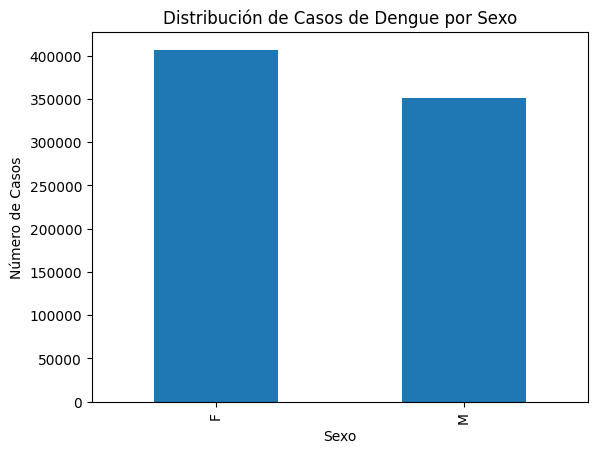

In [12]:
df['sexo'].value_counts().plot(kind='bar')
plt.xlabel('Sexo')
plt.ylabel('Número de Casos')
plt.title('Distribución de Casos de Dengue por Sexo')
plt.show()

Casos de dengue por departamento

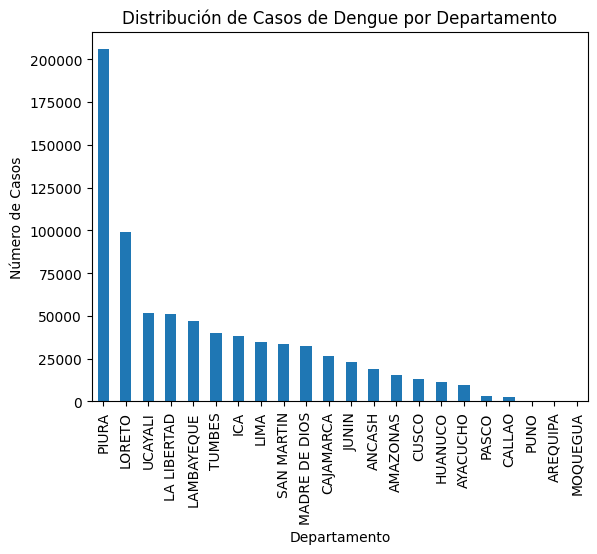

In [13]:
df['departamento'].value_counts().plot(kind='bar')
plt.xlabel('Departamento')
plt.ylabel('Número de Casos')
plt.title('Distribución de Casos de Dengue por Departamento')
plt.show()

Casos de dengue por provincia

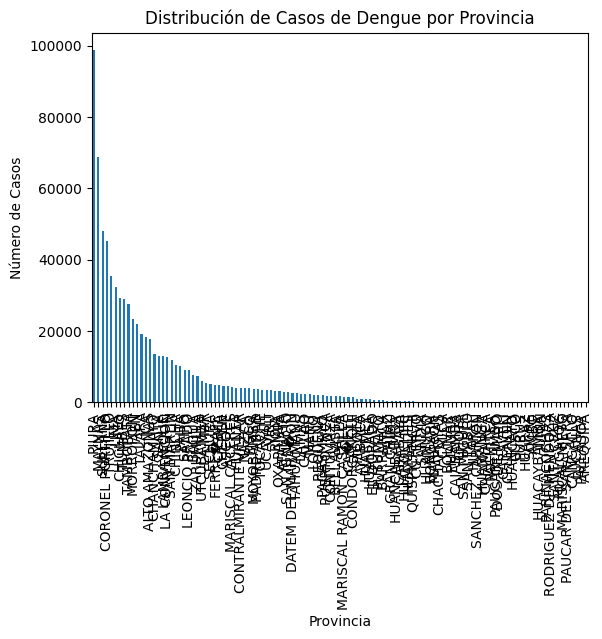

In [14]:
df['provincia'].value_counts().plot(kind='bar')
plt.xlabel('Provincia')
plt.ylabel('Número de Casos')
plt.title('Distribución de Casos de Dengue por Provincia')
plt.show()

Casos de Dengue por Edad

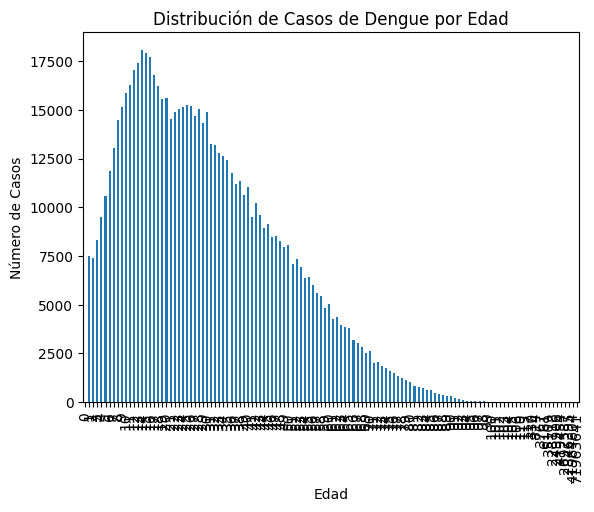

In [15]:
df['edad'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Edad')
plt.ylabel('Número de Casos')
plt.title('Distribución de Casos de Dengue por Edad')
plt.show()

###Identificando valores atipicos en Edad

In [16]:
media = df['edad'].mean()
desviacion = df['edad'].std()

# Definir valores atípicos como fuera de 3 desviaciones estándar
limite_inferior = media - 3 * desviacion
limite_superior = media + 3 * desviacion

valores_atipicos = df[(df['edad'] < limite_inferior) | (df['edad'] > limite_superior)]

print("Valores atípicos encontrados:")
print(valores_atipicos)

Valores atípicos encontrados:
       departamento provincia   distrito                   enfermedad   ano  \
268843        PIURA     PIURA   LA ARENA  DENGUE SIN SIGNOS DE ALARMA  2017   
272508        PIURA     PIURA   CATACAOS  DENGUE SIN SIGNOS DE ALARMA  2017   
288228        PIURA     PIURA  CURA MORI  DENGUE CON SIGNOS DE ALARMA  2017   
288290        PIURA     PIURA  CURA MORI  DENGUE SIN SIGNOS DE ALARMA  2017   
289244        PIURA     PIURA  CURA MORI  DENGUE SIN SIGNOS DE ALARMA  2017   

        semana diagnostic tipo_dx  diresa  ubigeo      edad tipo_edad sexo  
268843      16      A97.0       P  32.000  200109   2846395         A    M  
272508      17      A97.0       C  32.000  200105   2692587         A    M  
288228      20      A97.1       C  32.000  200107  71963641         A    M  
288290      20      A97.0       P  32.000  200107  41964604         A    F  
289244      20      A97.0       P  32.000  200107    419454         A    M  


In [17]:
df_filtrado = df[df['edad'] <= 90]

In [18]:
df_filtrado['edad'].mean()

np.float64(29.871859386082043)

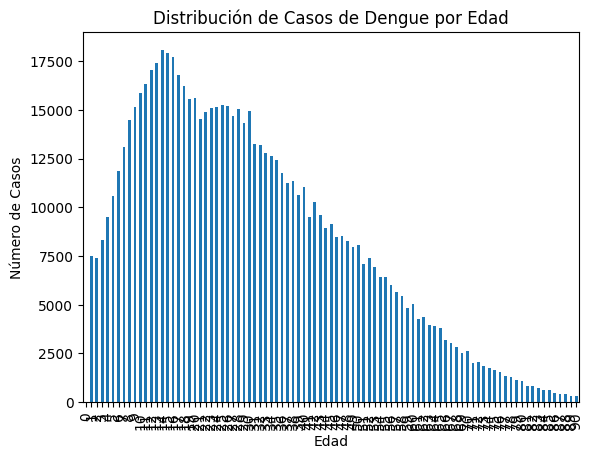

In [19]:
df_filtrado['edad'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Edad')
plt.ylabel('Número de Casos')
plt.title('Distribución de Casos de Dengue por Edad')
plt.show()

/tmp/ipykernel_2787/2542081451.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["grupo_edad"] = pd.cut(df_filtrado["edad"], bins=bins, labels=labels, right=False)


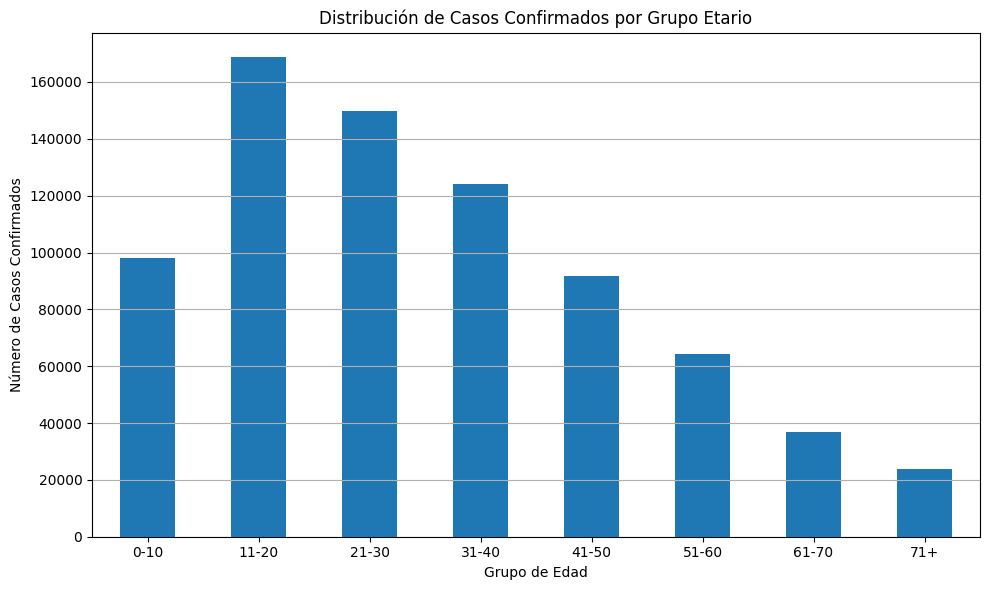

In [20]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 100]
labels = ['0-10','11-20','21-30','31-40','41-50','51-60','61-70','71+']
df_filtrado["grupo_edad"] = pd.cut(df_filtrado["edad"], bins=bins, labels=labels, right=False)

casos_por_edad = df_filtrado["grupo_edad"].value_counts().sort_index()

casos_por_edad.plot(kind="bar", figsize=(10,6))
plt.title("Distribución de Casos Confirmados por Grupo Etario")
plt.xlabel("Grupo de Edad")
plt.ylabel("Número de Casos Confirmados")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

###Idetentificando valores Atípicos

In [21]:
# Calcular Q1 (percentil 25) y Q3 (percentil 75)
Q1 = df_filtrado['edad'].quantile(0.25)
Q3 = df_filtrado['edad'].quantile(0.75)

# Calcular el IQR
IQR = Q3 - Q1

# Definir los límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar los valores atípicos
valores_atipicos = df_filtrado[(df_filtrado['edad'] < limite_inferior) | (df_filtrado['edad'] > limite_superior)]

print("Valores atípicos encontrados:")
print(valores_atipicos)

Valores atípicos encontrados:
       departamento provincia              distrito  \
132     LA LIBERTAD  TRUJILLO           EL PORVENIR   
935     LA LIBERTAD  TRUJILLO           EL PORVENIR   
2371         TUMBES    TUMBES                TUMBES   
3164          PIURA   SULLANA               SULLANA   
3194          PIURA   SULLANA          QUERECOTILLO   
...             ...       ...                   ...   
757258         LIMA      LIMA  SAN MARTIN DE PORRES   
757280         LIMA      LIMA            CARABAYLLO   
757284         LIMA      LIMA                 COMAS   
757418         LIMA      LIMA                 COMAS   
757861  LA LIBERTAD  TRUJILLO          LA ESPERANZA   

                         enfermedad   ano  semana diagnostic tipo_dx  diresa  \
132     DENGUE SIN SIGNOS DE ALARMA  2000      27      A97.0       P  13.000   
935     DENGUE SIN SIGNOS DE ALARMA  2000      25      A97.0       P  13.000   
2371    DENGUE SIN SIGNOS DE ALARMA  2000      11      A97.0       P 

###Identificando valores atípicos en el Ubigeo

In [22]:
df['ubigeo'] = df['ubigeo'].astype(str)
df['longitud_ubigeo'] = df['ubigeo'].apply(len)
print(df['longitud_ubigeo'].value_counts())

longitud_ubigeo
6    671790
5     86100
Name: count, dtype: int64


In [23]:
df[df['ubigeo'].str.len() == 5]['ubigeo'].unique()

array(['10702', '10201', '10701', '10703', '60603', '10707', '60801',
       '21801', '20801', '21808', '20802', '60901', '60808', '10205',
       '60903', '10202', '10203', '60805', '60802', '21809', '21803',
       '20803', '21806', '80902', '10706', '10705', '10403', '10704',
       '60902', '60804', '10101', '10401', '60812', '60810', '10204',
       '80910', '60606', '60613', '60807', '60415', '60905', '60811',
       '60809', '60602', '60904', '10206', '60906', '81203', '60806',
       '60803', '10605', '50902', '50407', '50101', '80907', '50507',
       '50503', '50408', '80901', '50502', '61306', '60101', '21101',
       '80904', '50509', '60502', '50510', '50409', '60507', '60508',
       '60401', '60501', '70106', '80909', '50501', '50110', '80101',
       '80913', '10306', '50808', '60607', '60109', '60703', '60409',
       '81106', '80906', '80908', '80408', '80914', '80903', '50115',
       '50201', '50701', '70101', '40313', '70107', '50505', '10402',
       '50906', '215

Codigo que asegura que todos los caracteres tengan 6 digitos y se agreguen a la izquierda de hacer falta

In [24]:
df['ubigeo'] = df['ubigeo'].apply(lambda x: x.zfill(6))

Codigo que visualiza el tamaño de ubigeos que existen en la data, los cuales son 6 ahora

In [25]:
df['ubigeo'].str.len().value_counts()

,count
ubigeo,
6,757890


###Limpieza

In [26]:
# 5. Renombrar columnas si deseas
df.rename(columns={
    'ano': 'año',
    'diagnostic': 'diagnostico'
}, inplace=True)

In [27]:
df['sexo_cod'] = df['sexo'].map({'F': 0, 'M': 1})  #F:0=mujeres y #M:1=hombres

In [28]:
df['tipo_dx_cod'] = df['tipo_dx'].map({'P': 0, 'C': 1})  # 0 = Presuntivo, 1 = Confirmado

###Medidas de Tendencias Estadísticas

In [29]:
# Medidas complementarias
print("Mediana de edad:", df_filtrado["edad"].median())
print("Moda de edad:", df_filtrado["edad"].mode()[0])
print("Rango:", df_filtrado["edad"].max() - df_filtrado["edad"].min())
print("Varianza:", df_filtrado["edad"].var())

Mediana de edad: 27.0
Moda de edad: 14
Rango: 90
Varianza: 345.62344122859395


###¿El dengue afecta más a hombres o mujeres en ciertos departamentos?

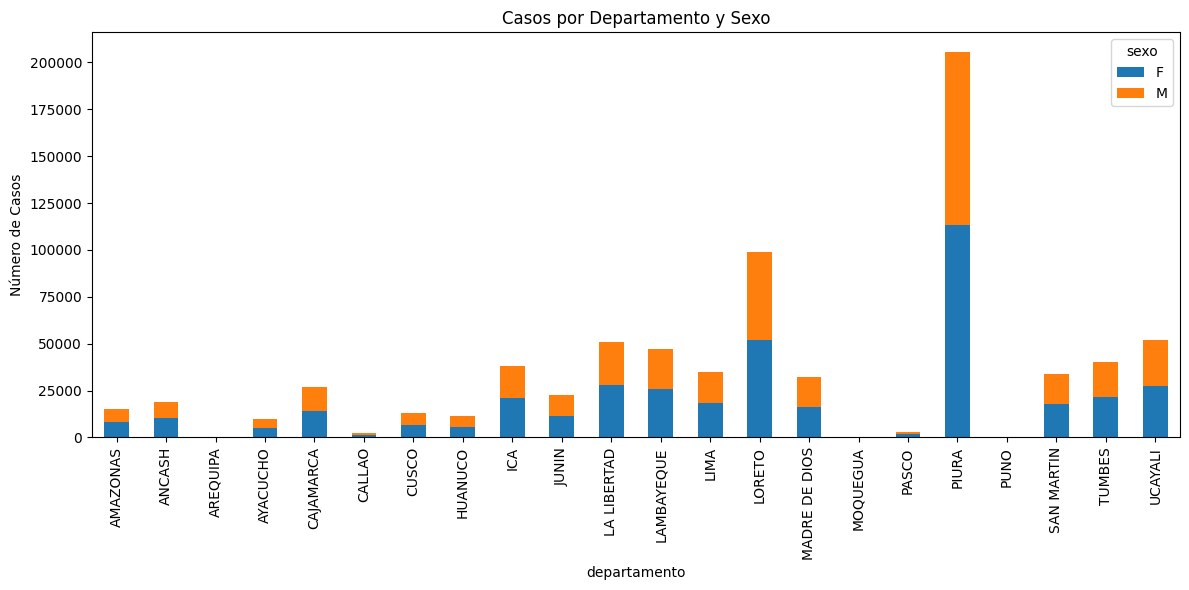

In [30]:
pd.crosstab(df['departamento'], df['sexo']).plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Casos por Departamento y Sexo")
plt.ylabel("Número de Casos")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

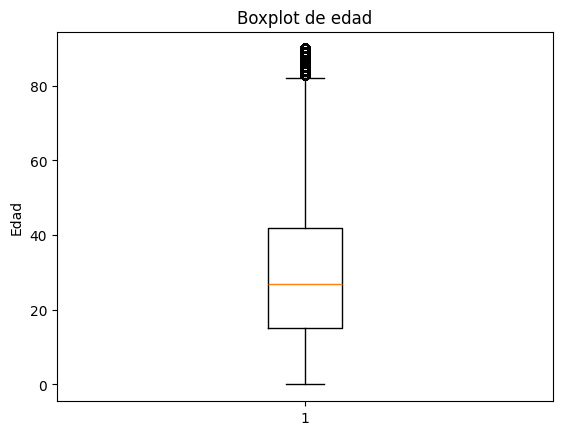

In [31]:
# Boxplot
plt.boxplot(df_filtrado["edad"])
plt.title("Boxplot de edad")
plt.ylabel("Edad")
plt.show()

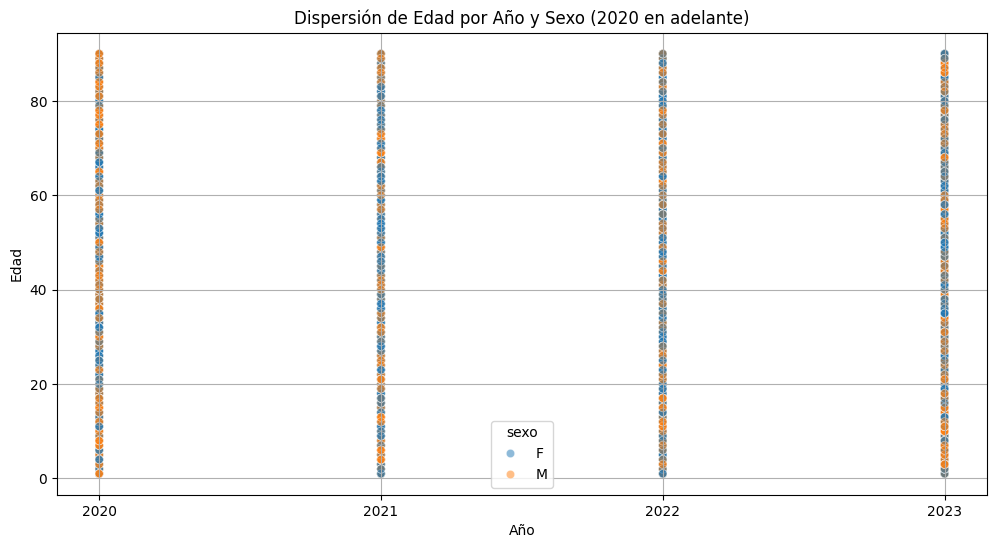

In [32]:
# Convertir columna 'año' a entero
df['año'] = df['año'].astype(int)

# Filtrar por edad y año
df_filtrado = df[(df['edad'] <= 90) & (df['año'] >= 2020)]

# Gráfico actualizado
import seaborn as sns

plt.figure(figsize=(12,6))
sns.scatterplot(data=df_filtrado, x='año', y='edad', hue='sexo', alpha=0.5)
plt.title("Dispersión de Edad por Año y Sexo (2020 en adelante)")
plt.xlabel("Año")
plt.ylabel("Edad")
plt.xticks(ticks=sorted(df_filtrado['año'].unique()))  # Asegura que los ticks sean enteros
plt.grid(True)
plt.show()

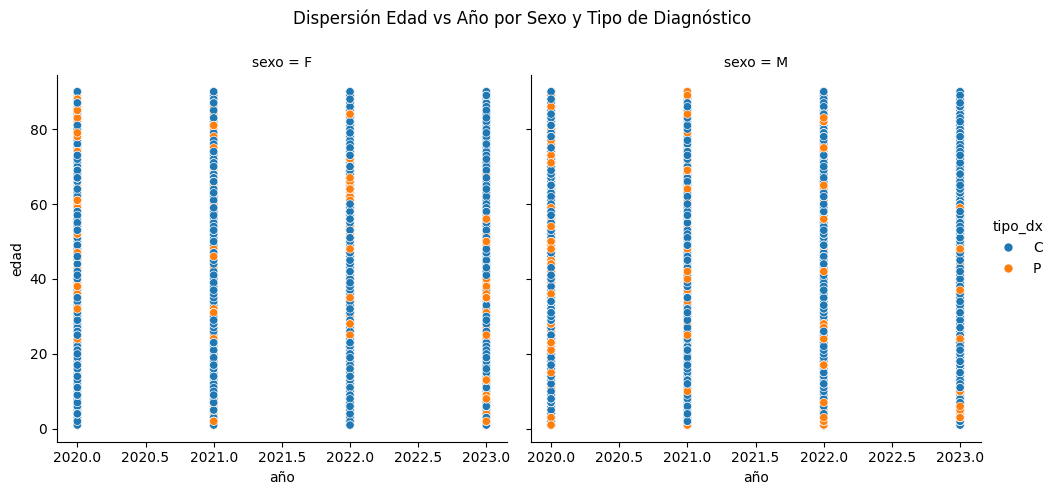

In [33]:
df_filtrado = df[(df['edad'] <= 90) & (df['año'] >= 2020)]
sns.relplot(data=df_filtrado, x='año', y='edad', hue='tipo_dx', col='sexo', kind='scatter', height=5, aspect=1)
plt.subplots_adjust(top=0.85)
plt.suptitle("Dispersión Edad vs Año por Sexo y Tipo de Diagnóstico")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


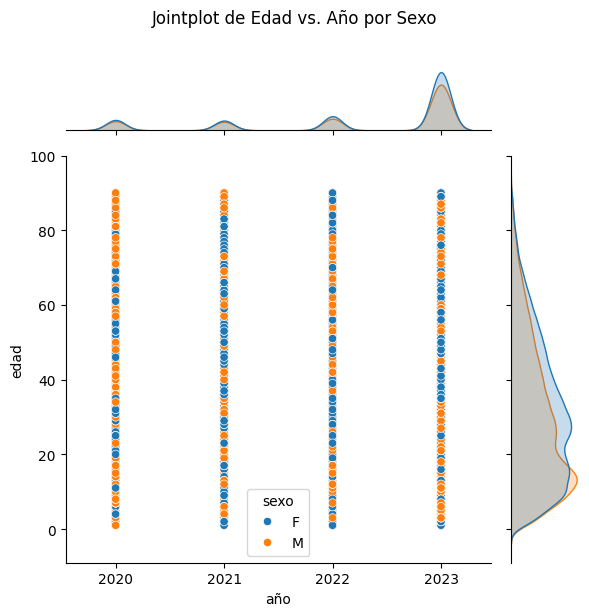

In [34]:

# Asegurar que 'año' es entero
df['año'] = df['año'].astype(int)

# Filtrar datos desde 2020 y edad menor o igual a 90
df_filtrado = df[(df['edad'] <= 90) & (df['año'] >= 2020)]

# Crear jointplot
g = sns.jointplot(data=df_filtrado, x='año', y='edad', kind='scatter', hue='sexo', height=6)

# Acceder al eje x del gráfico y cambiar los ticks
x_ticks = sorted(df_filtrado['año'].unique())
g.ax_joint.set_xticks(x_ticks)
g.ax_joint.set_xticklabels(x_ticks)

# Título y ajustes
plt.suptitle("Jointplot de Edad vs. Año por Sexo", y=1.02)
plt.tight_layout()
plt.show()